<a href="https://colab.research.google.com/github/mt508/machine-learning-/blob/main/Minist_binary_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml

In [2]:
mnist=fetch_openml("mnist_784",as_frame=False)


In [3]:
print(mnist.keys())

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [4]:
mnist_data=mnist.data
mnist_target=mnist.target

In [5]:
len(mnist_data)

70000

In [6]:
import matplotlib.pyplot as plt


In [7]:
def plot_image(image):
  rescale=image.reshape(28,28)
  return plt.imshow(rescale,cmap="binary")

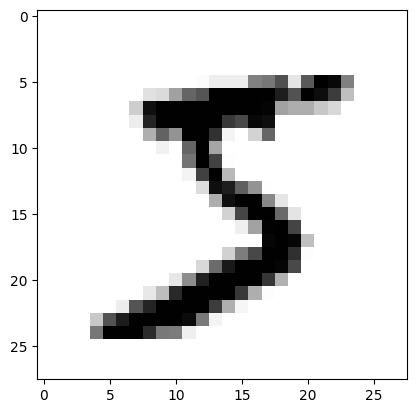

In [8]:
some_image=mnist_data[0]
plot_image(some_image)

In [9]:
mnist_target[0]

'5'

In [10]:
x_train,x_test,y_train,y_test=mnist_data[:60000],mnist_data[60000:],mnist_target[:60000],mnist_target[60000:]

In [11]:
from sklearn.linear_model import SGDClassifier

In [12]:
sgd=SGDClassifier(random_state=42)

In [13]:
y_train_5=(y_train=='5')

In [14]:
y_train_5

array([ True, False, False, ...,  True, False, False])

In [15]:
sgd.fit(x_train,y_train_5)

SGDClassifier(random_state=42)

In [16]:
from sklearn.model_selection import cross_val_score

In [17]:
score = cross_val_score(sgd,x_train,y_train_5,cv=3,scoring="accuracy")

In [18]:
score

array([0.95035, 0.96035, 0.9604 ])

In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [20]:
from sklearn.model_selection import  cross_val_predict

In [21]:
pred=cross_val_predict(sgd,x_train,y_train_5,cv=3)

In [22]:
confusion_matrix(y_train_5,pred)

array([[53892,   687],
       [ 1891,  3530]])

In [23]:
confusion_matrix(y_train_5,y_train_5) #orignal

array([[54579,     0],
       [    0,  5421]])

In [24]:
precision_score(y_train_5,pred)

0.8370879772350012

In [25]:
recall_score(y_train_5,pred)

0.6511713705958311

In [26]:
f1_score(y_train_5,pred)

0.7325171197343847

In [27]:
y_scores=cross_val_predict(sgd,x_train,y_train_5,cv=3,method="decision_function")
#

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447])

In [28]:
from sklearn.metrics import precision_recall_curve


In [29]:
precesion,recall,threshold=precision_recall_curve(y_true=y_train_5,y_score=y_scores)

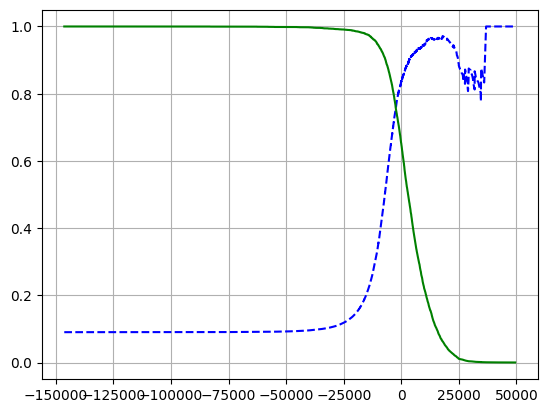

In [34]:
plt.plot(threshold,precesion[:-1],'b--',label="Precesion")
plt.plot(threshold,recall[:-1],'g-',label="Recall")
plt.grid(True)

plt.show()

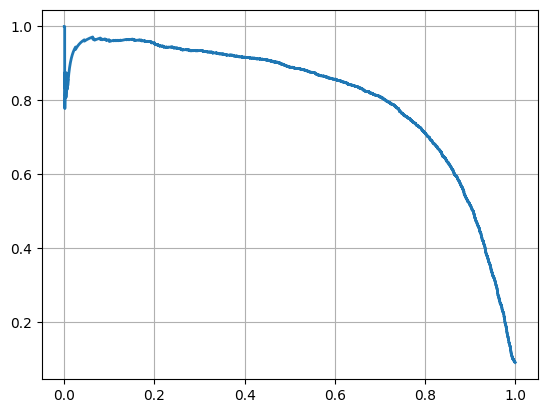

In [35]:
plt.plot(recall,precesion,linewidth=2)
plt.grid(True)

In [36]:
idx=(precesion>=0.90).argmax()
threshold_90=threshold[idx]

In [38]:
from sklearn.metrics import roc_curve

In [39]:
fpr,tpr,threshold_=roc_curve(y_train_5,y_score=y_scores)

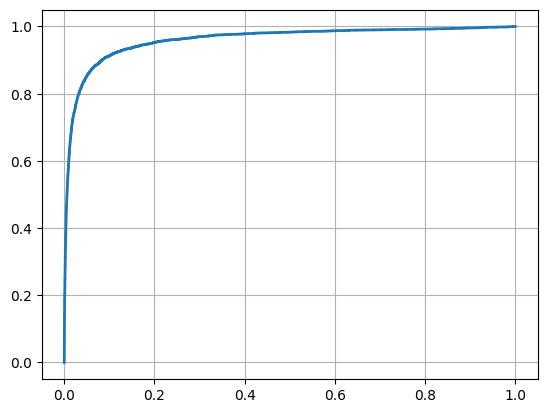

In [40]:
plt.plot(fpr,tpr,linewidth=2)
plt.grid(True)

In [41]:
from sklearn.metrics import roc_auc_score

In [42]:
roc_auc_score(y_train_5,y_scores)


np.float64(0.9604938554008616)